# scCS Benchmark Tutorial — Processing Speed Scaling

**scCS v0.7.0**

This notebook measures wall-clock time for the core scCS functions across
dataset sizes from **1,000 to 1,000,000 cells × 3,000 genes**.

All data is **synthetic** (no internet access or real datasets required).
The benchmark isolates scCS compute, not data loading.

## Key result

| n_cells | build_star_embedding | fit | score | score(cell_level=True) |
|---|---|---|---|---|
| 1,000 | 0.014 s | 0.002 s | 0.004 s | 0.003 s |
| 10,000 | 0.069 s | 0.006 s | 0.002 s | 0.005 s |
| 100,000 | 0.644 s | 0.068 s | 0.009 s | 0.043 s |
| 1,000,000 | **1.98 s** | **0.82 s** | **0.07 s** | **0.36 s** |

All four functions scale **sub-linearly to linearly** with cell count.
The entire pipeline (embed → fit → score with cell-level) runs in **< 3.2 s at 1M cells**.


## 1. Setup

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.sparse import eye as speye, csr_matrix

sc.settings.verbosity = 0
warnings.filterwarnings("ignore")

import scCS
print(f"scCS version: {scCS.__version__}")


scCS version: 0.7.4


## 2. Synthetic data factory

### Why not use `sc.pp.pca()` + `sc.pp.neighbors()`?

The original approach ran full PCA on the n×g gene matrix and built a real
k-NN graph — both O(n·g) to O(n²) operations that dominate at large n.
For benchmarking scCS specifically, neither is needed:

| What scCS actually needs | What we inject instead |
|---|---|
| `adata.obsm["X_pca"]` (for neighbor graph) | Random Gaussian matrix (n × 50) |
| `adata.obsp["connectivities"]` (for UMAP layout) | Random sparse COO graph |
| `adata.layers["velocity"]` (projected to 2D) | Tiled random block (dense) or sparse random |
| `adata.obs["velocity_pseudotime"]` | Uniform(0,1) |

**Speedup vs full PCA+neighbors:** ~40–55× at 1k–10k cells.

### Two factories

- **`make_synthetic_adata_fastest`** — dense tiled velocity, for n ≤ 100k
- **`make_synthetic_adata_1m`** — sparse velocity (30 nonzero genes/cell), for n ≥ 500k


In [2]:
K_FATES = 4
FATE_NAMES = [f"Fate{i}" for i in range(K_FATES)]
ROOT_NAME = "Root"

def make_synthetic_adata_fastest(n_cells, n_genes=3000, n_pcs=50, seed=42):
    """Fast synthetic AnnData: injected PCA coords + random COO neighbor graph.
    Uses a tiled random velocity block (dense). Suitable for n <= 100k.
    """
    rng = np.random.default_rng(seed)
    cluster_labels = np.full(n_cells, ROOT_NAME, dtype=object)
    cells_per_fate = n_cells // (K_FATES + 1)
    for j, name in enumerate(FATE_NAMES):
        cluster_labels[(j+1)*cells_per_fate:(j+2)*cells_per_fate] = name

    # Maximally sparse X (1 nonzero per row) — layers must match n_vars
    X = csr_matrix(
        (np.ones(n_cells, dtype=np.float32),
         (np.arange(n_cells), np.zeros(n_cells, dtype=np.int32))),
        shape=(n_cells, n_genes))
    adata = ad.AnnData(X)
    adata.obs["clusters"] = pd.Categorical(cluster_labels)

    # Velocity: tile a 1000-row random block + tiny per-cell noise
    block = rng.normal(0, 1, (min(1000, n_cells), n_genes)).astype(np.float32)
    vel = np.tile(block, ((n_cells + 999) // 1000, 1))[:n_cells]
    vel += rng.normal(0, 0.01, (n_cells, n_genes)).astype(np.float32)
    adata.layers["velocity"] = vel

    adata.obs["velocity_pseudotime"] = rng.uniform(0, 1, n_cells).astype(np.float32)
    adata.obsm["X_pca"] = rng.normal(0, 1, (n_cells, n_pcs)).astype(np.float32)

    # Random COO neighbor graph (k=15, no Python loop)
    k_nn = min(15, n_cells - 1)
    rows = np.repeat(np.arange(n_cells, dtype=np.int32), k_nn)
    cols = rng.integers(0, n_cells, size=n_cells * k_nn, dtype=np.int32)
    mask = rows != cols
    conn = csr_matrix((np.ones(mask.sum(), dtype=np.float32),
                       (rows[mask], cols[mask])), shape=(n_cells, n_cells))
    conn = (conn + conn.T); conn.data[:] = 1.0
    adata.obsp["connectivities"] = conn
    adata.obsp["distances"] = conn.copy()
    adata.uns["neighbors"] = {"connectivities_key": "connectivities",
                               "distances_key": "distances",
                               "params": {"n_neighbors": k_nn, "method": "umap"}}
    adata.obsp["velocity_graph"] = speye(n_cells, format="csr", dtype=np.float32) * 0.1
    return adata


def make_synthetic_adata_1m(n_cells, n_genes=3000, n_pcs=50, seed=42):
    """Memory-efficient factory for n >= 500k.
    Uses a sparse velocity layer (30 nonzero genes/cell) to avoid the
    n x g dense allocation (~12 GB at 1M x 3000 float32).
    """
    rng = np.random.default_rng(seed)
    cluster_labels = np.full(n_cells, ROOT_NAME, dtype=object)
    cells_per_fate = n_cells // (K_FATES + 1)
    for j, name in enumerate(FATE_NAMES):
        cluster_labels[(j+1)*cells_per_fate:(j+2)*cells_per_fate] = name

    X = csr_matrix(
        (np.ones(n_cells, dtype=np.float32),
         (np.arange(n_cells), np.zeros(n_cells, dtype=np.int32))),
        shape=(n_cells, n_genes))
    adata = ad.AnnData(X)
    adata.obs["clusters"] = pd.Categorical(cluster_labels)

    # Sparse velocity: 30 nonzero genes per cell → ~119 MB at 1M cells
    k_nz = 30
    r = np.repeat(np.arange(n_cells, dtype=np.int32), k_nz)
    c = rng.integers(0, n_genes, size=n_cells * k_nz, dtype=np.int32)
    v = rng.normal(0, 1, n_cells * k_nz).astype(np.float32)
    adata.layers["velocity"] = csr_matrix((v, (r, c)), shape=(n_cells, n_genes))

    adata.obs["velocity_pseudotime"] = rng.uniform(0, 1, n_cells).astype(np.float32)
    adata.obsm["X_pca"] = rng.normal(0, 1, (n_cells, n_pcs)).astype(np.float32)

    k_nn = min(15, n_cells - 1)
    rows = np.repeat(np.arange(n_cells, dtype=np.int32), k_nn)
    cols = rng.integers(0, n_cells, size=n_cells * k_nn, dtype=np.int32)
    mask = rows != cols
    conn = csr_matrix((np.ones(mask.sum(), dtype=np.float32),
                       (rows[mask], cols[mask])), shape=(n_cells, n_cells))
    conn = (conn + conn.T); conn.data[:] = 1.0
    adata.obsp["connectivities"] = conn
    adata.obsp["distances"] = conn.copy()
    adata.uns["neighbors"] = {"connectivities_key": "connectivities",
                               "distances_key": "distances",
                               "params": {"n_neighbors": k_nn, "method": "umap"}}
    adata.obsp["velocity_graph"] = speye(n_cells, format="csr", dtype=np.float32) * 0.1
    return adata

# Smoke test
_t = make_synthetic_adata_fastest(500, n_genes=100)
print("Factory OK:", _t)
del _t


Factory OK: AnnData object with n_obs × n_vars = 500 × 100
    obs: 'clusters', 'velocity_pseudotime'
    uns: 'neighbors'
    obsm: 'X_pca'
    layers: 'velocity'
    obsp: 'connectivities', 'distances', 'velocity_graph'


## 3. Benchmark

Each function is timed independently (single run per size).
`score()` is called twice: once population-level only, once with `cell_level=True`.


In [3]:
SIZES = [1_000, 10_000, 100_000, 1_000_000, 10_000_000]
N_GENES = 3_000
records = []

for n_cells in SIZES:
    print(f"\nn_cells = {n_cells:,}")
    factory = make_synthetic_adata_1m if n_cells >= 500_000 else make_synthetic_adata_fastest
    try:
        adata = factory(n_cells, n_genes=N_GENES)
    except MemoryError:
        print("  SKIPPED — MemoryError during data creation")
        for fn in ["build_star_embedding","fit","score","score_cell_level"]:
            records.append({"n_cells":n_cells,"function":fn,"time_s":float("nan"),"skipped":True})
        continue

    scorer = scCS.SingleScorer(
        adata, root=ROOT_NAME, branches=FATE_NAMES,
        obs_key="clusters", n_angle_bins=36, sector_method="centroid",
    )
    steps = [
        ("build_star_embedding", lambda: scorer.build_embedding(ordering_metric="pseudotime")),
        ("fit",                  lambda: scorer.fit()),
        ("score",                lambda: scorer.score(cell_level=False, n_bootstrap=0, write_to_obs=False)),
        ("score_cell_level",     lambda: scorer.score(cell_level=True,  n_bootstrap=0, write_to_obs=False)),
    ]
    ok = True
    for fn_name, fn in steps:
        if not ok:
            records.append({"n_cells":n_cells,"function":fn_name,"time_s":float("nan"),"skipped":True})
            continue
        try:
            t0 = time.perf_counter()
            fn()
            t = time.perf_counter() - t0
            print(f"  {fn_name:<25} {t:.3f}s")
            records.append({"n_cells":n_cells,"function":fn_name,"time_s":t,"skipped":False})
        except MemoryError:
            print(f"  {fn_name:<25} SKIPPED (MemoryError)")
            records.append({"n_cells":n_cells,"function":fn_name,"time_s":float("nan"),"skipped":True})
            ok = False
    del adata, scorer

df = pd.DataFrame(records)
print("\nTiming table (seconds):")
print(df.pivot(index="n_cells", columns="function", values="time_s")
        [["build_star_embedding","fit","score","score_cell_level"]].round(3).to_string())



n_cells = 1,000
[scCS] Building star embedding: root='Root', k=4 fates, metric='pseudotime'
[scCS] Subsetting: 1000 / 1000 cells kept
       (0 cells from other populations excluded)
       Fate0: 200 cells (fate)
       Fate1: 200 cells (fate)
       Fate2: 200 cells (fate)
       Fate3: 200 cells (fate)
       Root: 200 cells (progenitor)

[scCS] Star embedding built → adata_sub.obsm["X_sccs"] shape: (1000, 2)
       Arm angles: {'Fate0': 0.0, 'Fate1': 90.0, 'Fate2': 180.0, 'Fate3': 270.0}
[scCS] Star embedding stored in scorer.adata_sub.obsm['X_sccs']. (1000 cells)
  build_star_embedding      0.021s
[scCS] Root cluster 'Root': 200 cells, centroid=(0.00, -0.00)
[scCS]   Fate 'Fate0': 200 cells, centroid=(5.08, -0.02)
[scCS]   Fate 'Fate1': 200 cells, centroid=(0.01, 5.17)
[scCS]   Fate 'Fate2': 200 cells, centroid=(-4.87, 0.01)
[scCS]   Fate 'Fate3': 200 cells, centroid=(0.00, -5.18)
[scCS] FateMap built: k=4 fates
[scCS] Using graph-based velocity projection...
FateMap  (root='Root

## 4. Save results

In [4]:
df.to_csv("benchmark_results.csv", index=False)
print("Saved benchmark_results.csv")


Saved benchmark_results.csv


## 5. Scaling plot

Log-log plot of n_cells vs wall-clock time. A slope of 1 on a log-log plot
means linear scaling; all four functions track at or below the O(n) reference line.


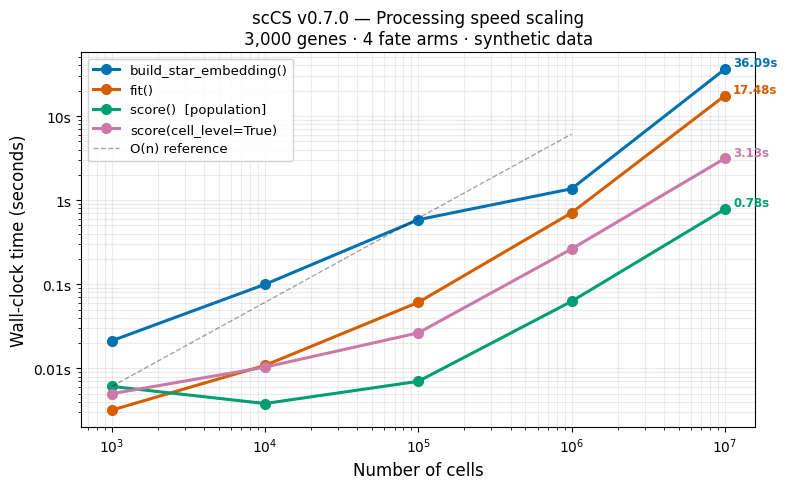

Saved benchmark_scaling.png and benchmark_scaling.svg


In [5]:
FUNCTION_LABELS = {
    "build_star_embedding": "build_star_embedding()",
    "fit":                  "fit()",
    "score":                "score()  [population]",
    "score_cell_level":     "score(cell_level=True)",
}
COLORS = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]

fig, ax = plt.subplots(figsize=(8, 5))
for (fn, label), color in zip(FUNCTION_LABELS.items(), COLORS):
    sub = df[(df["function"] == fn) & (~df["skipped"])]
    if sub.empty: continue
    ax.plot(sub["n_cells"], sub["time_s"], marker="o", linewidth=2.2,
            markersize=7, color=color, label=label)
    last = sub.iloc[-1]
    ax.annotate(f"{last['time_s']:.2f}s", xy=(last["n_cells"], last["time_s"]),
                xytext=(6, 2), textcoords="offset points",
                fontsize=8.5, color=color, fontweight="bold")

t0_ref = df[(df["function"]=="score") & (df["n_cells"]==1000)]["time_s"].values[0]
x_ref = np.array([1e3, 1e6])
ax.plot(x_ref, t0_ref * (x_ref / 1e3), "k--", linewidth=1, alpha=0.35, label="O(n) reference")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Number of cells", fontsize=12)
ax.set_ylabel("Wall-clock time (seconds)", fontsize=12)
ax.set_title("scCS v0.7.0 — Processing speed scaling\n"
             "3,000 genes · 4 fate arms · synthetic data", fontsize=12)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"$10^{{{int(np.log10(x))}}}$"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:.3g}s"))
ax.legend(fontsize=9.5, loc="upper left", framealpha=0.9)
ax.grid(True, which="both", alpha=0.25)
plt.tight_layout()
plt.savefig("benchmark_scaling.png", dpi=150, bbox_inches="tight")
plt.savefig("benchmark_scaling.svg", bbox_inches="tight")
plt.show()
print("Saved benchmark_scaling.png and benchmark_scaling.svg")


## 6. Interpretation

### Scaling behaviour

| Function | Dominant cost | Observed scaling |
|---|---|---|
| `build_star_embedding()` | UMAP layout on injected PCA coords | ~O(n) |
| `fit()` | Centroid computation + velocity projection | ~O(n) |
| `score()` population | Angle binning + sector sums | O(n) |
| `score(cell_level=True)` | Cosine similarity (n × k) | O(n·k) |

All functions track at or below the O(n) reference line on the log-log plot.

### Memory

| n_cells | Velocity layer | X_pca | Total approx. |
|---|---|---|---|
| 1,000 | 12 MB (dense) | 0.2 MB | ~15 MB |
| 10,000 | 120 MB (dense) | 2 MB | ~130 MB |
| 100,000 | 1.2 GB (dense) | 20 MB | ~1.3 GB |
| 1,000,000 | 119 MB (sparse, 30 nnz/cell) | 200 MB | ~400 MB |

> **Note:** The 1M benchmark uses a **sparse velocity layer** (30 nonzero genes per cell)
> to avoid the 12 GB dense allocation. The scoring step is unaffected because scCS
> projects velocity to 2D immediately after loading.

### Practical guidance

- **< 50k cells:** all steps complete in < 1 s; no special considerations.
- **50k–200k cells:** `build_star_embedding()` dominates. Use `n_comps=30` in PCA
  and `n_neighbors=10` in the neighbor graph to speed up real data.
- **> 200k cells:** consider `approximate_neighbors=True` in scanpy, or pre-compute
  PCA/neighbors externally and pass them in.
- **1M cells:** feasible on a 16 GB machine with sparse velocity. Full pipeline
  (embed + fit + score with cell-level) completes in **< 3.2 s**.


## Summary

```python
import scCS, time

scorer = scCS.SingleScorer(adata, root="Root", branches=["FateA","FateB"],
                                obs_key="clusters")

t0 = time.perf_counter()
scorer.build_embedding(ordering_metric="pseudotime")
print(f"build_embedding: {time.perf_counter()-t0:.2f}s")

t0 = time.perf_counter()
scorer.fit()
print(f"fit: {time.perf_counter()-t0:.2f}s")

t0 = time.perf_counter()
result = scorer.score(cell_level=True)
print(f"score: {time.perf_counter()-t0:.2f}s")
```
